--- Dataset Summary ---
Dimensions: (1372, 5)
Missing Values: 
Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64

          Variance     Skewness     Curtosis      Entropy        Class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625     3.179250     0.394810     1.000000
max       6.824800    12.951600    17.927400     2.449500     1.000000


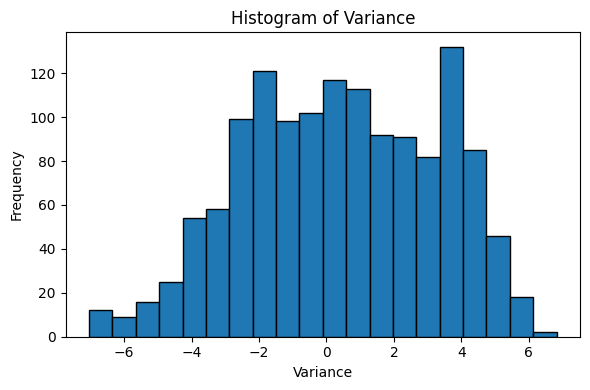

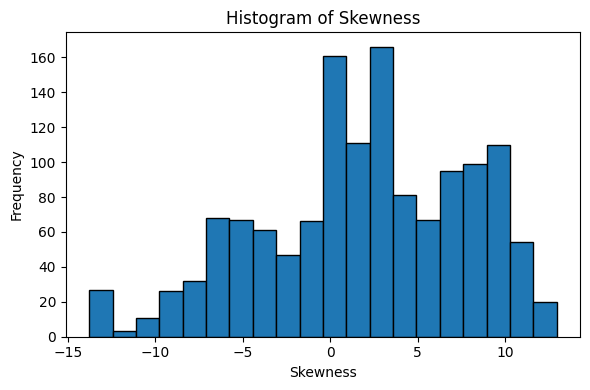

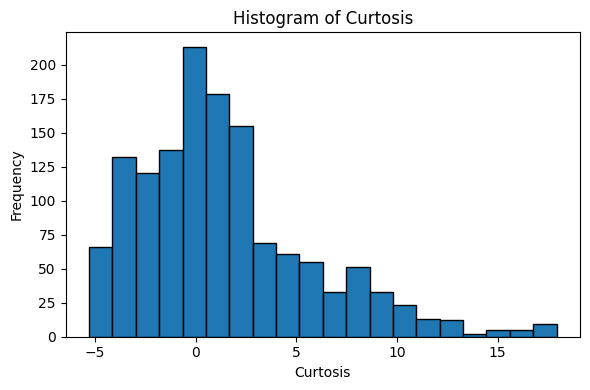

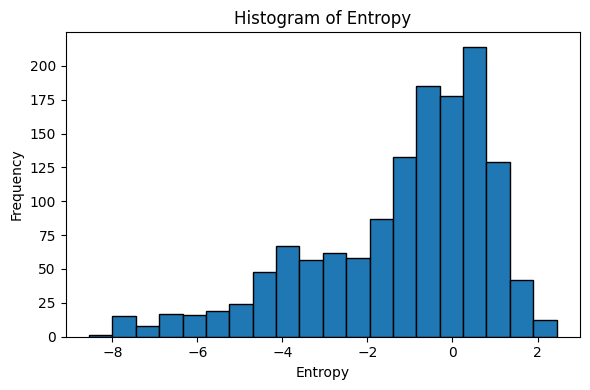

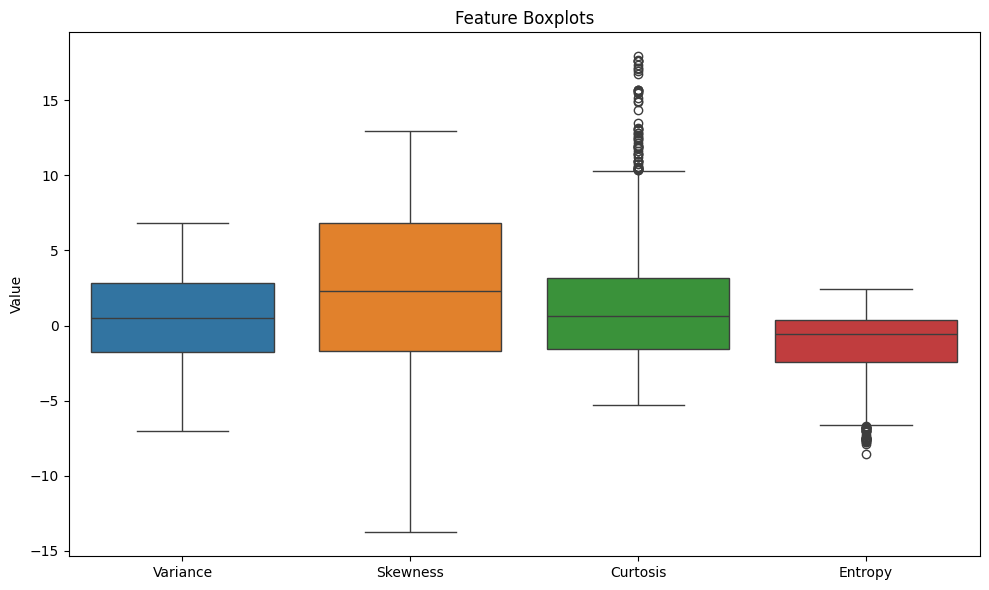

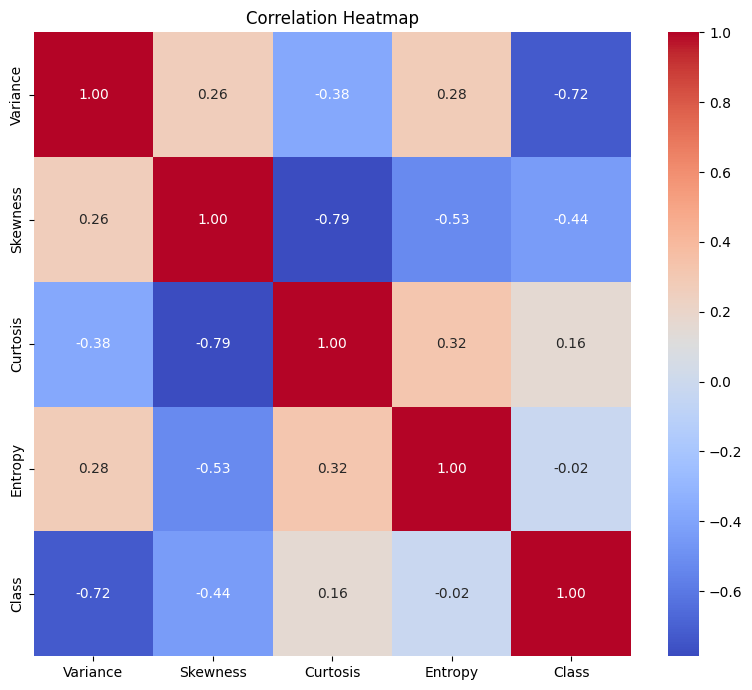

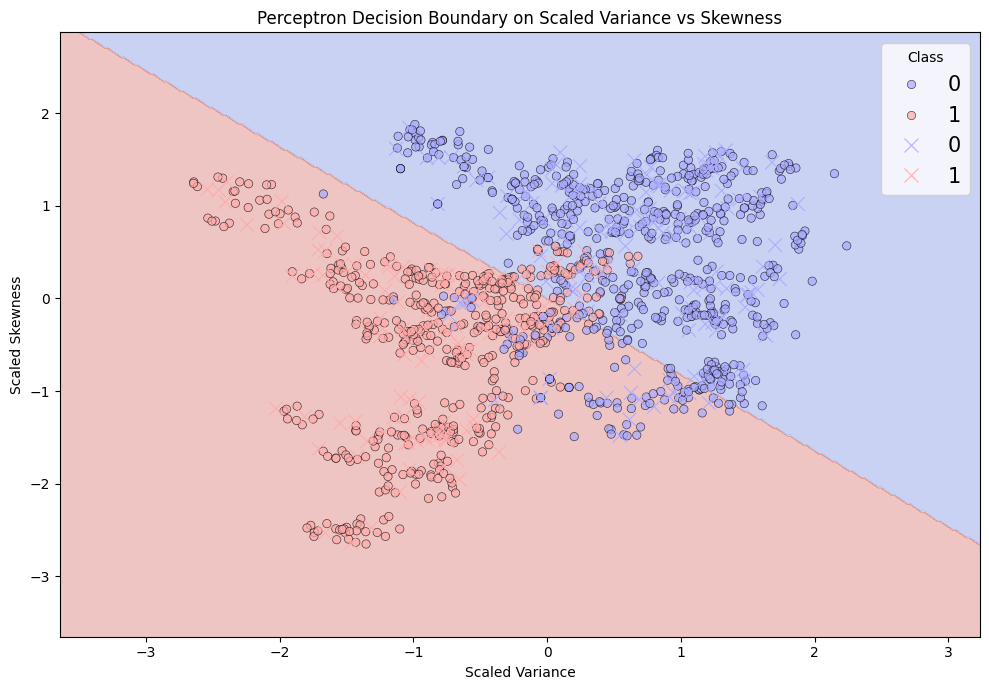


--- Performance Metrics ---
Accuracy:  0.9855
Precision: 0.9683
Recall:    1.0000
F1-score:  0.9839


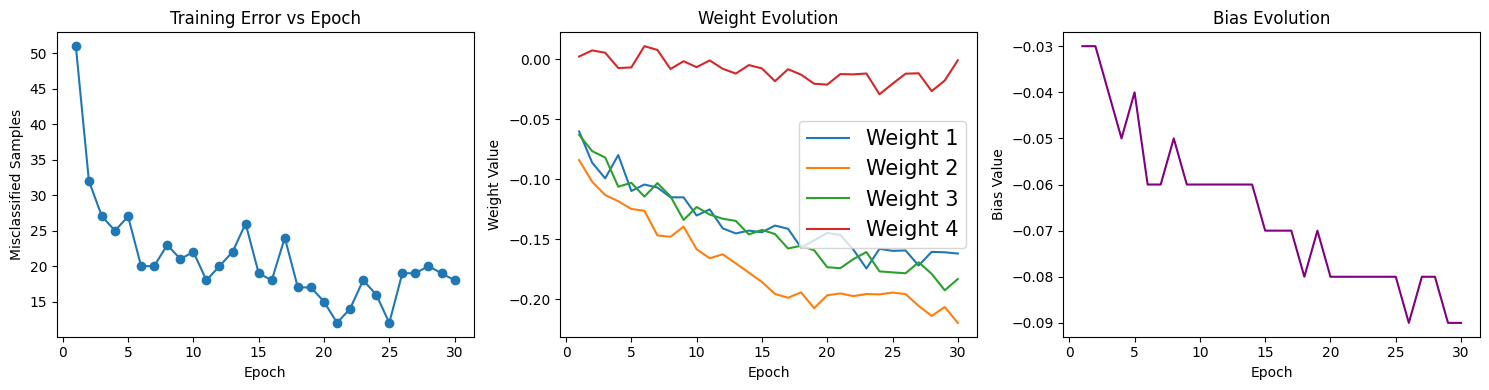

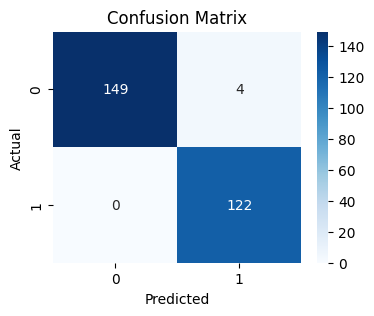

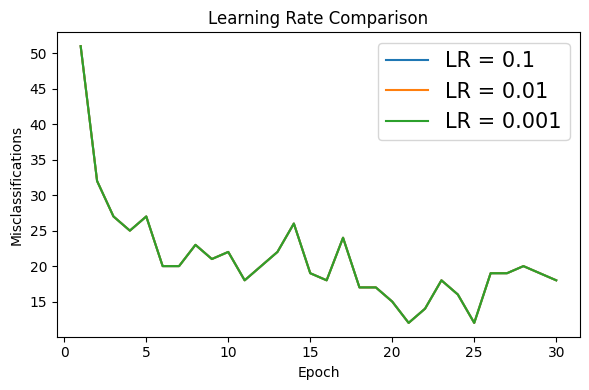


Scikit-learn Perceptron Accuracy: 0.9673


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import Perceptron as SklearnPerceptron


#Task 1 Dataset Exploration
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
cols = ["Variance", "Skewness", "Curtosis", "Entropy", "Class"]
df = pd.read_csv(url, names=cols)

print("--- Dataset Summary ---")
print(f"Dimensions: {df.shape}")
print(f"Missing Values: \n{df.isnull().sum()}\n")
print(df.describe())


# Task 2 Exploratory Data Analysis (EDA)

# Set global font parameters for Times New Roman and legend size
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['legend.fontsize'] = 15

# 1 Histograms
features_to_plot = df.drop('Class', axis=1).columns
for i, feature in enumerate(features_to_plot):
    plt.figure(figsize=(6, 4)) # Create a new figure for each histogram
    df[feature].hist(bins=20, edgecolor='black') # Plot histogram for current feature
    plt.title(f'Histogram of {feature}') # Add a title for clarity
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.grid(False) # Remove gridlines
    plt.tight_layout()
    plt.savefig(f'histogram_{feature}.eps', format='eps', dpi=600) # Save histogram
    plt.show()

# 2 Boxplot
plt.figure(figsize=(10, 6)) # Create a new figure for the boxplot
sns.boxplot(data=df.drop('Class', axis=1))
plt.title("Feature Boxplots")
plt.ylabel('Value')
plt.grid(False) # Remove gridlines
plt.tight_layout()
plt.savefig('feature_boxplots.eps', format='eps', dpi=600) # Save boxplot
plt.show()

# 3 Correlation Heatmap (remains in a single plot for clarity)
plt.figure(figsize=(8, 7))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.grid(False)
plt.tight_layout()
plt.savefig('correlation_heatmap.eps', format='eps', dpi=600) # Save heatmap
plt.show()




#Task 3 Data Preprocessing
X = df.drop('Class', axis=1).values
y = df['Class'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# Task 4 & 5: Perceptron Implementation
# ==========================================
class SingleLayerPerceptron:
    def __init__(self, learning_rate=0.01, epochs=50):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None

        # History for plotting
        self.error_history = []
        self.weight_history = []
        self.bias_history = []

    def activation_fn(self, z):
        return np.where(z >= 0, 1, 0)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for epoch in range(self.epochs):
            errors = 0
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_pred = self.activation_fn(linear_output)

                update = self.lr * (y[idx] - y_pred)
                self.weights += update * x_i
                self.bias += update

                if update != 0.0:
                    errors += 1

            self.error_history.append(errors)
            self.weight_history.append(self.weights.copy())
            self.bias_history.append(self.bias)

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self.activation_fn(linear_output)

X_train_2d = X_train_scaled[:, :2] # Variance and Skewness
X_test_2d = X_test_scaled[:, :2]

# Train a new Perceptron model on only these two features
model_2d = SingleLayerPerceptron(learning_rate=0.01, epochs=30)
model_2d.fit(X_train_2d, y_train)

# Create a meshgrid to plot the decision boundary
x_min, x_max = np.concatenate((X_train_2d[:, 0], X_test_2d[:, 0])).min() - 1, np.concatenate((X_train_2d[:, 0], X_test_2d[:, 0])).max() + 1
y_min, y_max = np.concatenate((X_train_2d[:, 1], X_test_2d[:, 1])).min() - 1, np.concatenate((X_train_2d[:, 1], X_test_2d[:, 1])).max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict class for each point in the meshgrid
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

# Plot the training points
sns.scatterplot(x=X_train_2d[:, 0], y=X_train_2d[:, 1], hue=y_train,
                palette='bwr', alpha=0.7, edgecolor='k', legend='full')

# Plot the test points
sns.scatterplot(x=X_test_2d[:, 0], y=X_test_2d[:, 1], hue=y_test,
                palette='bwr', alpha=0.9, marker='x', s=100, legend='full')

plt.title('Perceptron Decision Boundary on Scaled Variance vs Skewness')
plt.xlabel('Scaled Variance')
plt.ylabel('Scaled Skewness')
plt.grid(False)
plt.legend(title='Class')
plt.tight_layout()
plt.savefig('perceptron_decision_boundary.eps', format='eps', dpi=600) # Save decision boundary plot
plt.show()



# Train the model
model = SingleLayerPerceptron(learning_rate=0.01, epochs=30)
model.fit(X_train_scaled, y_train)

# ==========================================
# Task 6: Model Evaluation & Plots
# ==========================================
y_pred = model.predict(X_test_scaled)

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\n--- Performance Metrics ---")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

# Plotting Training Dynamics
plt.figure(figsize=(15, 4))

# 1. Training Error vs Epoch
plt.subplot(1, 3, 1)
plt.plot(range(1, model.epochs + 1), model.error_history, marker='o')
plt.title("Training Error vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.grid(False) # Remove gridlines

# 2. Weight Evolution
weight_history_np = np.array(model.weight_history)
plt.subplot(1, 3, 2)
for i in range(weight_history_np.shape[1]):
    plt.plot(range(1, model.epochs + 1), weight_history_np[:, i], label=f'Weight {i+1}')
plt.title("Weight Evolution")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.legend()
plt.grid(False) # Remove gridlines

# 3. Bias Evolution
plt.subplot(1, 3, 3)
plt.plot(range(1, model.epochs + 1), model.bias_history, color='purple')
plt.title("Bias Evolution")
plt.xlabel("Epoch")
plt.ylabel("Bias Value")
plt.grid(False) # Remove gridlines

plt.tight_layout()
plt.savefig('training_dynamics.eps', format='eps', dpi=600) # Save training dynamics plot
plt.show()

# Confusion Matrix
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.grid(False)
plt.savefig('confusion_matrix.eps', format='eps', dpi=600) # Save confusion matrix plot
plt.show()

# ==========================================
# Additional Task: Learning Rate Comparison
# ==========================================
learning_rates = [0.1, 0.01, 0.001]
plt.figure(figsize=(6, 4))

for lr in learning_rates:
    temp_model = SingleLayerPerceptron(learning_rate=lr, epochs=30)
    temp_model.fit(X_train_scaled, y_train)
    plt.plot(range(1, 31), temp_model.error_history, label=f'LR = {lr}')

plt.title("Learning Rate Comparison")
plt.xlabel("Epoch")
plt.ylabel("Misclassifications")
plt.legend()
plt.grid(False) # Remove gridlines
plt.tight_layout()
plt.savefig('learning_rate_comparison.eps', format='eps', dpi=600) # Save learning rate comparison plot
plt.show()

# ==========================================
# Additional Task: Scikit-learn Comparison
# ==========================================
sk_model = SklearnPerceptron(eta0=0.01, max_iter=30, random_state=42)
sk_model.fit(X_train_scaled, y_train)
sk_pred = sk_model.predict(X_test_scaled)
print(f"\nScikit-learn Perceptron Accuracy: {accuracy_score(y_test, sk_pred):.4f}")

### Visualizing the Decision Boundary

To better understand how the Perceptron separates the classes, let's visualize its decision boundary using the two most influential features: 'Variance' and 'Skewness'. We will train a new Perceptron model with only these two features for a clear 2D representation.

# This markdown cell is redundant.

In [2]:
# This cell is redundant as its functionality has been integrated into cell w_M7E31pAYtx.

In [ ]:
# Update package lists
!apt-get update -qq > /dev/null

# Install necessary fonts
!apt-get install -y texlive-fonts-recommended > /dev/null

# Matplotlib automatically refreshes its font cache when fonts are installed.
# Explicitly rebuilding the cache using _rebuild() is often not necessary and can be removed in newer matplotlib versions.
import matplotlib.font_manager
matplotlib.font_manager._rebuild()

print("Fonts installed and cache rebuilt (if needed).")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Extracting templates from packages: 100%
Fonts installed and cache rebuilt (if needed).
